In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Softmax Regression

In [2]:
df = pd.read_csv("./LOCAL_LR.csv")
df.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_current_mA,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,class,confidence,inference_time_ms,batch
0,4/23/2026 22:17,40,67,29.8,44,-194,0,0.000000,0.000000,1,21,Interpreter not initialized,-1.000000,0.000000,1
1,4/23/2026 22:17,80,67,29.7,43,-159,0,0.534703,0.000000,1,21,Compute-Heavy Activity,0.861328,1.994791,1
2,4/23/2026 22:17,57,67,29.7,43,-138,1,0.620210,0.160651,1,21,Low Activity,0.725098,10.662968,1
3,4/23/2026 22:17,81,67,30.9,43,786,1,25.137827,59.247780,1,21,Network Activity,1.000000,13.025938,1
4,4/23/2026 22:17,32,67,30.9,43,3460,1,3.729353,6.138255,1,21,Low Activity,1.000000,2.873282,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16363 entries, 0 to 16362
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            16363 non-null  str    
 1   cpu_usage            16363 non-null  int64  
 2   memory_usage         16363 non-null  int64  
 3   temperature          16363 non-null  float64
 4   battery_level        16363 non-null  int64  
 5   battery_current_mA   16363 non-null  int64  
 6   battery_charging     16363 non-null  int64  
 7   upload_speed_kbps    16363 non-null  float64
 8   download_speed_kbps  16363 non-null  float64
 9   screen_on            16363 non-null  int64  
 10  brightness           16363 non-null  int64  
 11  class                16363 non-null  str    
 12  confidence           15459 non-null  float64
 13  inference_time_ms    16363 non-null  float64
 14  batch                16363 non-null  int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 1

### Data Cleaning

In [4]:
df.drop(df[df['confidence'] == -1].index, inplace=True)
df_cleaned = df.dropna()
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 15457 entries, 1 to 16362
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            15457 non-null  str    
 1   cpu_usage            15457 non-null  int64  
 2   memory_usage         15457 non-null  int64  
 3   temperature          15457 non-null  float64
 4   battery_level        15457 non-null  int64  
 5   battery_current_mA   15457 non-null  int64  
 6   battery_charging     15457 non-null  int64  
 7   upload_speed_kbps    15457 non-null  float64
 8   download_speed_kbps  15457 non-null  float64
 9   screen_on            15457 non-null  int64  
 10  brightness           15457 non-null  int64  
 11  class                15457 non-null  str    
 12  confidence           15457 non-null  float64
 13  inference_time_ms    15457 non-null  float64
 14  batch                15457 non-null  int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 1.9 MB

In [5]:
df_cleaned.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_current_mA,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,class,confidence,inference_time_ms,batch
1,4/23/2026 22:17,80,67,29.7,43,-159,0,0.534703,0.000000,1,21,Compute-Heavy Activity,0.861328,1.994791,1
2,4/23/2026 22:17,57,67,29.7,43,-138,1,0.620210,0.160651,1,21,Low Activity,0.725098,10.662968,1
3,4/23/2026 22:17,81,67,30.9,43,786,1,25.137827,59.247780,1,21,Network Activity,1.000000,13.025938,1
4,4/23/2026 22:17,32,67,30.9,43,3460,1,3.729353,6.138255,1,21,Low Activity,1.000000,2.873282,1
5,4/23/2026 22:18,27,67,31.5,44,40,1,1.361430,10.767344,1,21,Low Activity,0.999512,14.895469,1


### Analysis

In [6]:
print(df_cleaned['class'].value_counts())

class
Low Activity              8990
Network Activity          4385
Compute-Heavy Activity    2082
Name: count, dtype: int64


In [7]:
result_analysis = df_cleaned.drop(columns=['battery_level','battery_charging','screen_on','brightness','timestamp', 'confidence', 'inference_time_ms', 'batch']).groupby('class').agg(['mean'])
df_analysis = result_analysis.reset_index()
df_analysis.head()

,class,cpu_usage,memory_usage,temperature,battery_current_mA,upload_speed_kbps,download_speed_kbps
,,mean,mean,mean,mean,mean,mean
0,Compute-Heavy Activity,59.721902,71.400096,34.753554,-293.033141,1.571072,3.913505
1,Low Activity,40.188765,70.683648,35.014138,256.136040,1.226336,4.009319
2,Network Activity,49.008666,72.051995,35.405177,-102.312657,17.267472,494.947762


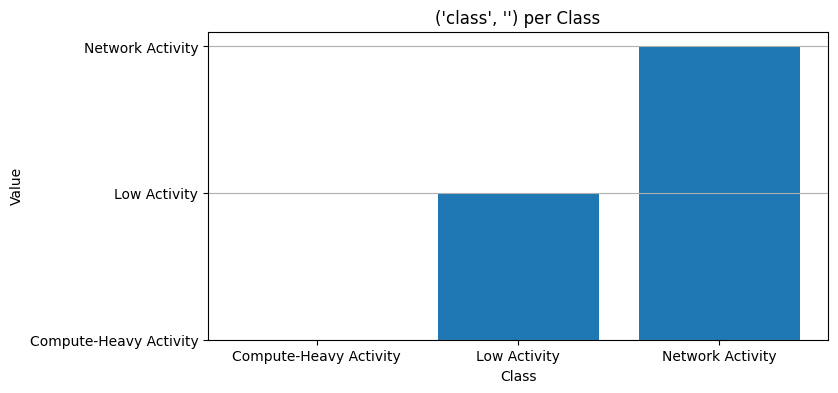

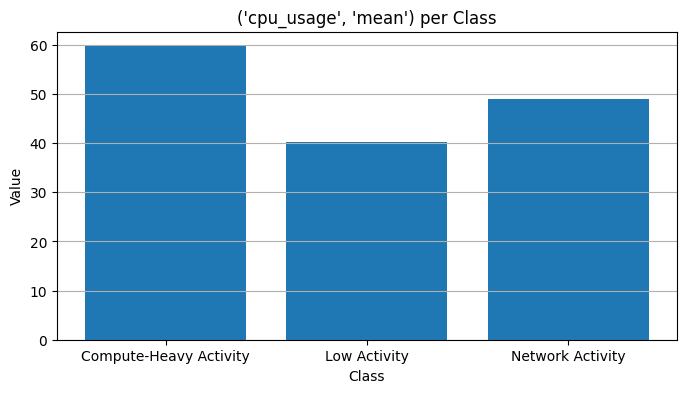

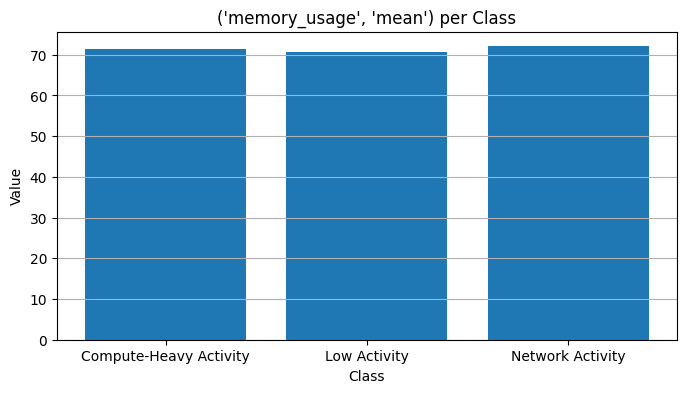

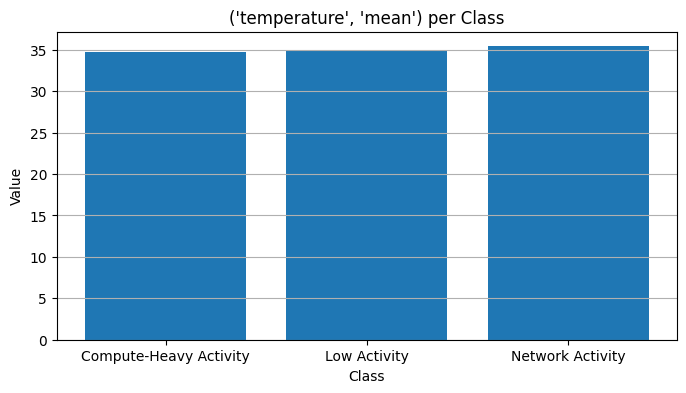

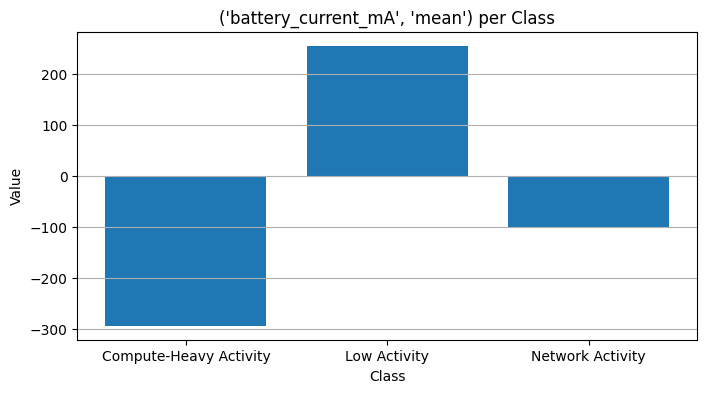

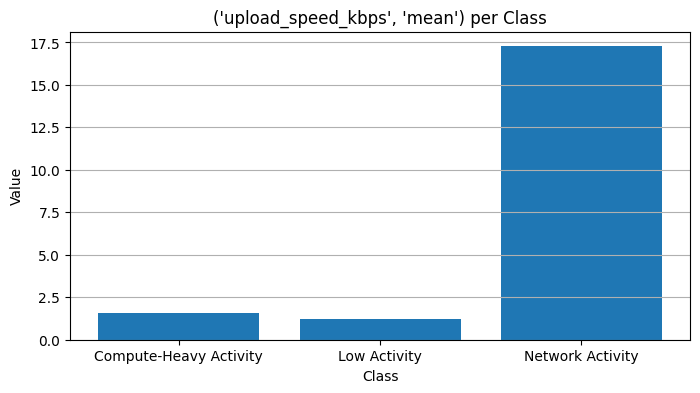

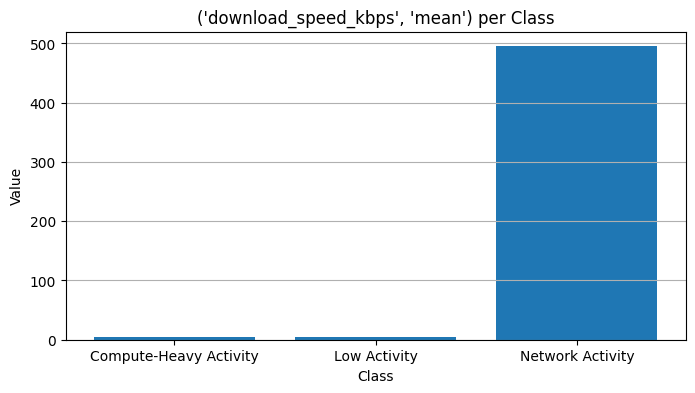

In [8]:
for col in df_analysis.columns:
    if col != 'class':
        plt.figure(figsize=(8, 4))
        plt.bar(df_analysis['class'], df_analysis[col])
        plt.title(f"{col} per Class")
        plt.xlabel("Class")
        plt.ylabel("Value")
        plt.grid(axis='y')
        plt.show()

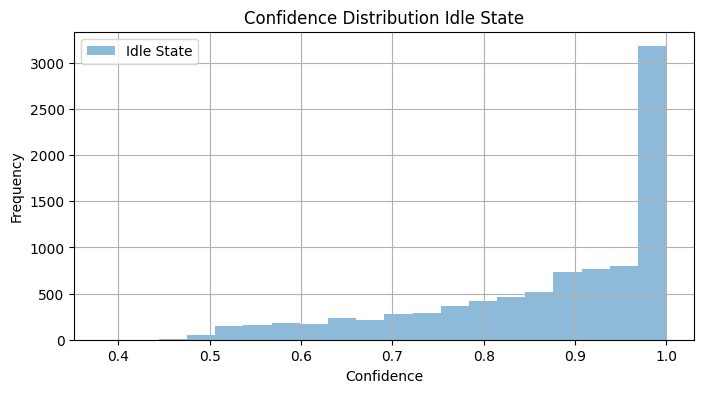

In [9]:
# Confidence Histogram Per Class
class_idle = df_cleaned[df_cleaned['class'] == 'Low Activity']['confidence']
class_compute = df_cleaned[df_cleaned['class'] == 'Compute-Heavy Activity']['confidence']
class_network = df_cleaned[df_cleaned['class'] == 'Network Activity']['confidence']

plt.figure(figsize=(8, 4))
plt.hist(class_idle, bins=20, alpha=0.5, label='Idle State')

plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution Idle State")
plt.legend()
plt.grid(True)
plt.show()

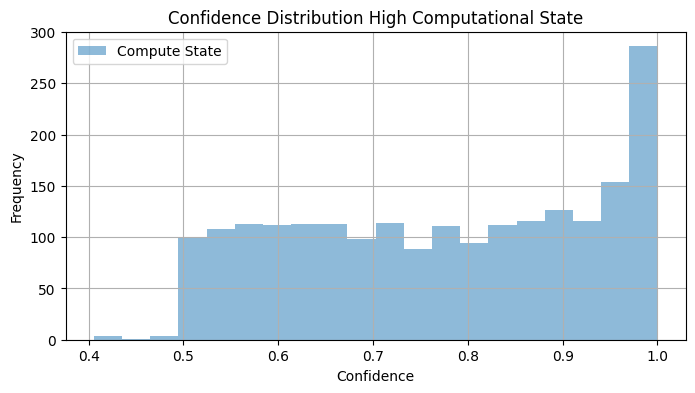

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(class_compute, bins=20, alpha=0.5, label='Compute State')
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution High Computational State")
plt.legend()
plt.grid(True)

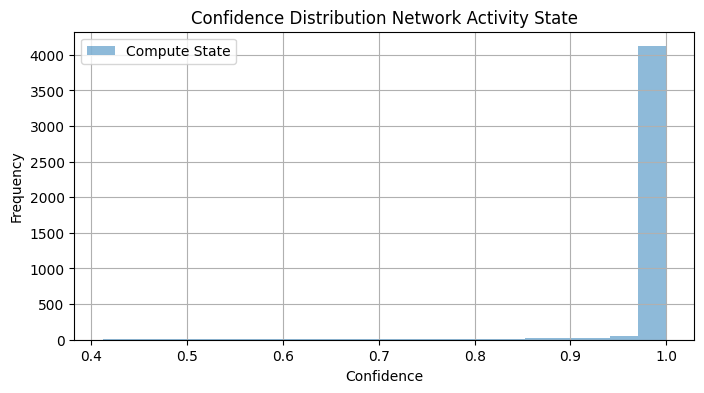

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(class_network, bins=20, alpha=0.5, label='Compute State')
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution Network Activity State")
plt.legend()
plt.grid(True)

In [29]:
# Inference
df_cleaned['inference_time_ms'].describe()

count    15457.000000
mean         8.166591
std         90.156469
min          0.693021
25%          2.252657
50%          3.206458
75%         12.249271
max       8981.640881
Name: inference_time_ms, dtype: float64

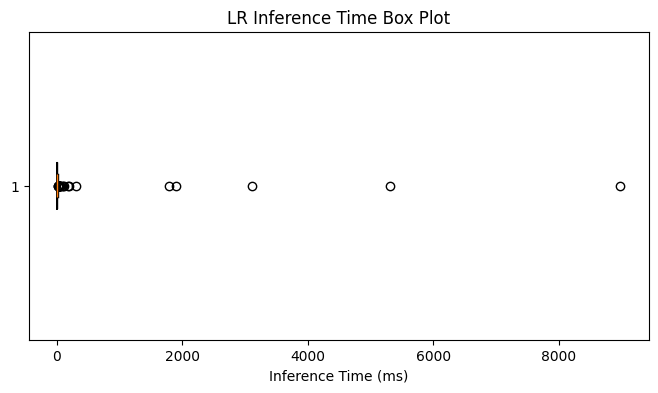

In [35]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_cleaned['inference_time_ms'], notch=True, vert=False)
plt.title("LR Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()

## ANN

In [14]:
df_ann = pd.read_csv("./LOCAL_ANN.csv")
df_ann.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_current_mA,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,class,confidence,inference_time_ms,batch
0,4/22/2026 11:27,71,68,34.3,30,-175,0,0.000000,0.00000,1,21,Interpreter not initialized,-1.000000,0.000000,1
1,4/22/2026 11:27,27,67,34.3,30,-187,0,0.412872,0.00000,1,21,Low Activity,1.000000,5.400886,1
2,4/22/2026 11:27,100,69,34.8,30,-337,0,0.323829,0.00000,1,21,Compute-Heavy Activity,1.000000,1.529114,1
3,4/22/2026 11:27,24,69,34.8,30,-249,0,5.739067,12.75656,0,21,Low Activity,0.983887,12.983698,1
4,4/22/2026 11:27,35,69,34.8,30,-575,0,0.154678,0.00000,1,21,Compute-Heavy Activity,0.958496,13.746406,1


In [15]:
df_ann.info()

<class 'pandas.DataFrame'>
RangeIndex: 26827 entries, 0 to 26826
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            26827 non-null  str    
 1   cpu_usage            26827 non-null  int64  
 2   memory_usage         26827 non-null  int64  
 3   temperature          26827 non-null  float64
 4   battery_level        26827 non-null  int64  
 5   battery_current_mA   26827 non-null  int64  
 6   battery_charging     26827 non-null  int64  
 7   upload_speed_kbps    26827 non-null  float64
 8   download_speed_kbps  26827 non-null  float64
 9   screen_on            26827 non-null  int64  
 10  brightness           26827 non-null  int64  
 11  class                26827 non-null  str    
 12  confidence           23120 non-null  float64
 13  inference_time_ms    26827 non-null  float64
 14  batch                26827 non-null  int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 3

### Data Cleaning

In [16]:
df_ann.drop(df_ann[df_ann['confidence'] == -1].index, inplace=True)
df_ann_cleaned = df_ann.dropna()
df_ann_cleaned.info()

<class 'pandas.DataFrame'>
Index: 23118 entries, 1 to 26826
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            23118 non-null  str    
 1   cpu_usage            23118 non-null  int64  
 2   memory_usage         23118 non-null  int64  
 3   temperature          23118 non-null  float64
 4   battery_level        23118 non-null  int64  
 5   battery_current_mA   23118 non-null  int64  
 6   battery_charging     23118 non-null  int64  
 7   upload_speed_kbps    23118 non-null  float64
 8   download_speed_kbps  23118 non-null  float64
 9   screen_on            23118 non-null  int64  
 10  brightness           23118 non-null  int64  
 11  class                23118 non-null  str    
 12  confidence           23118 non-null  float64
 13  inference_time_ms    23118 non-null  float64
 14  batch                23118 non-null  int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 2.8 MB

In [17]:
df_ann_cleaned.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_current_mA,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,class,confidence,inference_time_ms,batch
1,4/22/2026 11:27,27,67,34.3,30,-187,0,0.412872,0.00000,1,21,Low Activity,1.000000,5.400886,1
2,4/22/2026 11:27,100,69,34.8,30,-337,0,0.323829,0.00000,1,21,Compute-Heavy Activity,1.000000,1.529114,1
3,4/22/2026 11:27,24,69,34.8,30,-249,0,5.739067,12.75656,0,21,Low Activity,0.983887,12.983698,1
4,4/22/2026 11:27,35,69,34.8,30,-575,0,0.154678,0.00000,1,21,Compute-Heavy Activity,0.958496,13.746406,1
5,4/22/2026 11:27,48,69,34.8,30,-216,0,0.333166,0.00000,1,21,Low Activity,0.997070,2.052865,1


### Analysis

In [18]:
print(df_ann_cleaned['class'].value_counts())

class
Low Activity              10418
Network Activity           8076
Compute-Heavy Activity     4624
Name: count, dtype: int64


In [19]:
result_analysis_ann = df_ann_cleaned.drop(
    columns=['battery_level', 'battery_charging', 'screen_on', 'brightness', 'timestamp', 'confidence',
             'inference_time_ms', 'batch']).groupby('class').agg(['mean'])
df_analysis_ann = result_analysis_ann.reset_index()
df_analysis_ann.head()

,class,cpu_usage,memory_usage,temperature,battery_current_mA,upload_speed_kbps,download_speed_kbps
,,mean,mean,mean,mean,mean,mean
0,Compute-Heavy Activity,62.584775,73.186635,35.181272,-419.299740,5.534387,77.475928
1,Low Activity,37.681321,69.971684,32.970167,-161.223555,1.389650,2.074585
2,Network Activity,50.929297,72.209633,35.861317,154.613299,16.256461,85.103708


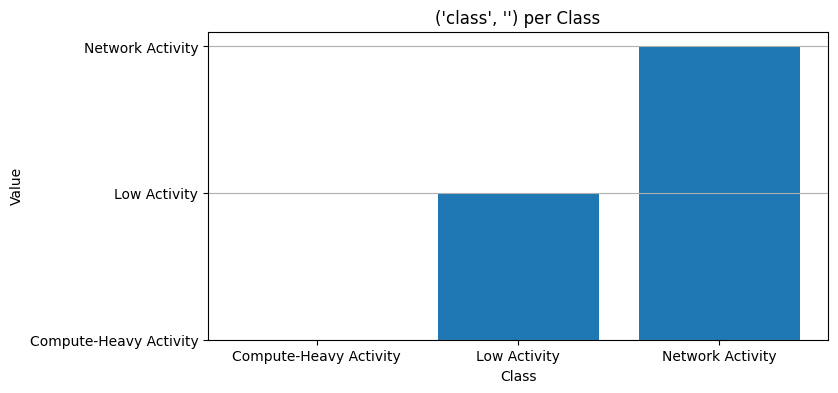

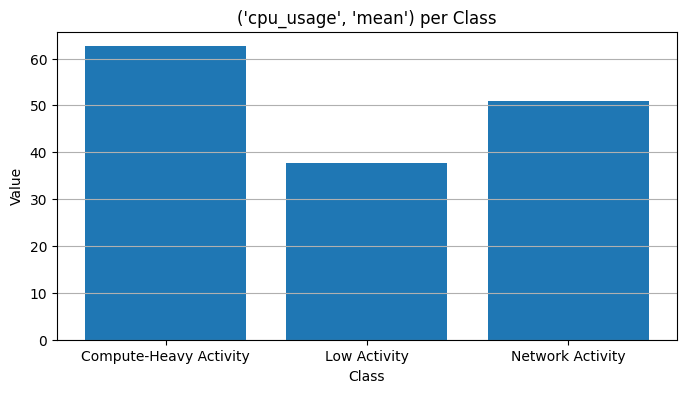

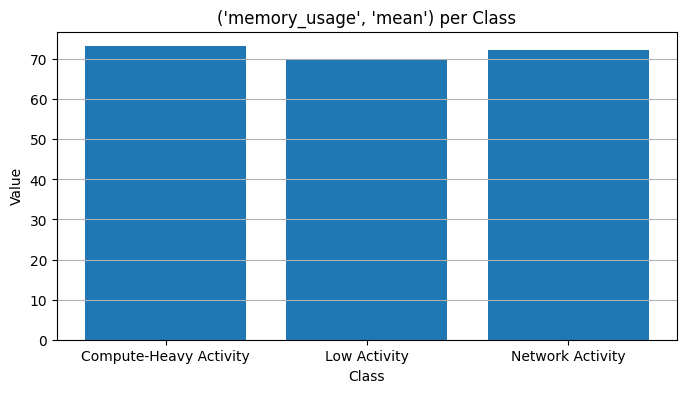

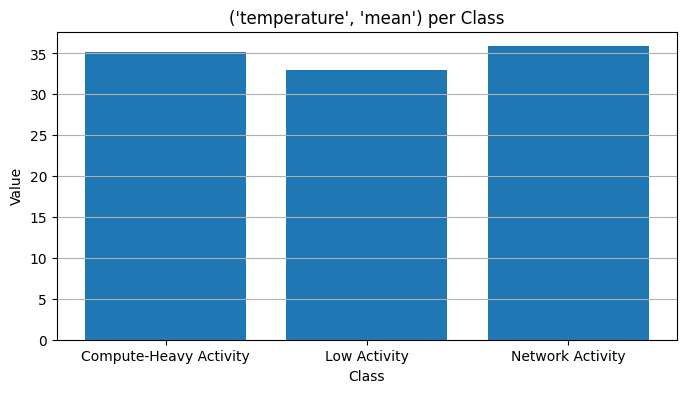

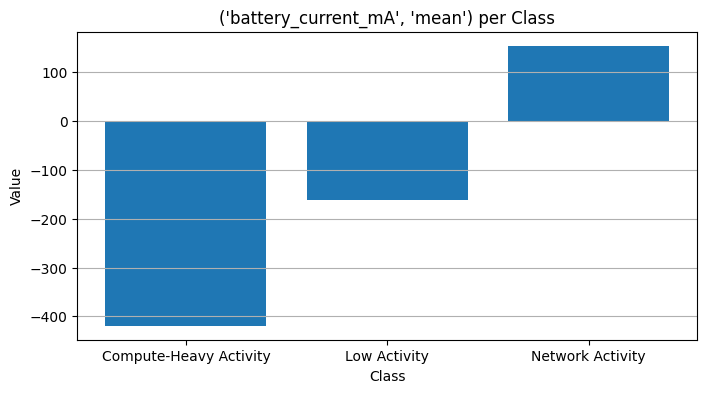

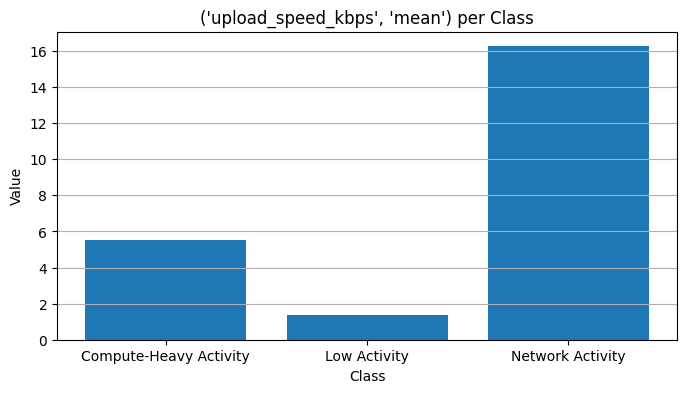

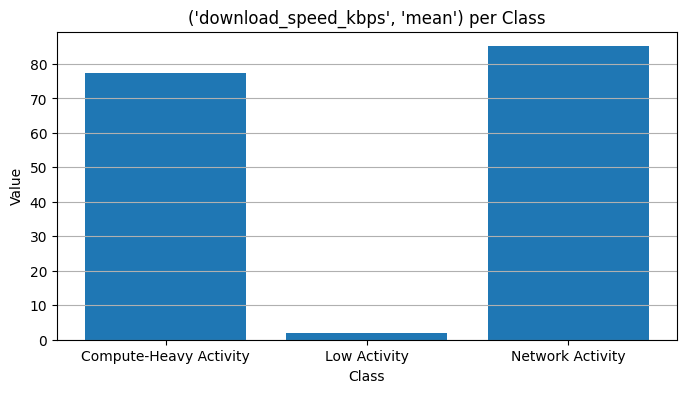

In [20]:
for col in df_analysis_ann.columns:
    if col != 'class':
        plt.figure(figsize=(8, 4))
        plt.bar(df_analysis_ann['class'], df_analysis_ann[col])
        plt.title(f"{col} per Class")
        plt.xlabel("Class")
        plt.ylabel("Value")
        plt.grid(axis='y')
        plt.show()

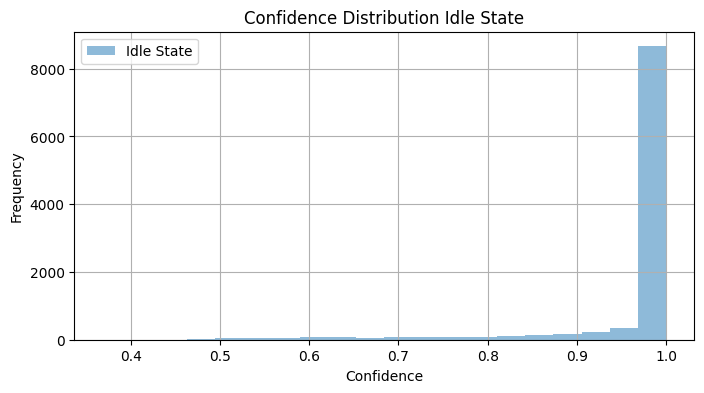

In [24]:
# Confidence Histogram Per Class
class_idle = df_ann_cleaned[df_ann_cleaned['class'] == 'Low Activity']['confidence']
class_compute = df_ann_cleaned[df_ann_cleaned['class'] == 'Compute-Heavy Activity']['confidence']
class_network = df_ann_cleaned[df_ann_cleaned['class'] == 'Network Activity']['confidence']

plt.figure(figsize=(8, 4))
plt.hist(class_idle, bins=20, alpha=0.5, label='Idle State')

plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution Idle State")
plt.legend()
plt.grid(True)
plt.show()

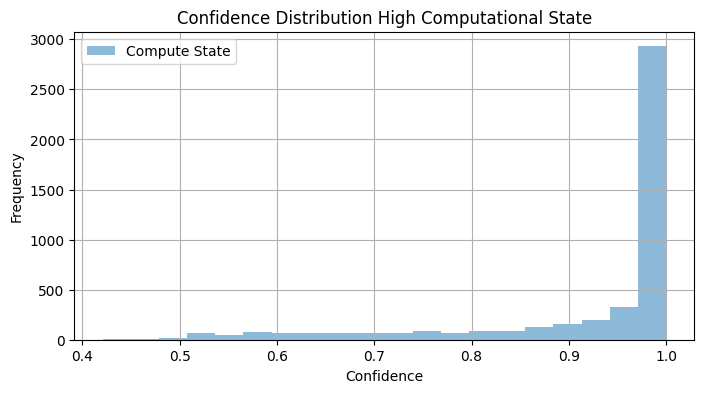

In [25]:
plt.figure(figsize=(8, 4))
plt.hist(class_compute, bins=20, alpha=0.5, label='Compute State')
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution High Computational State")
plt.legend()
plt.grid(True)

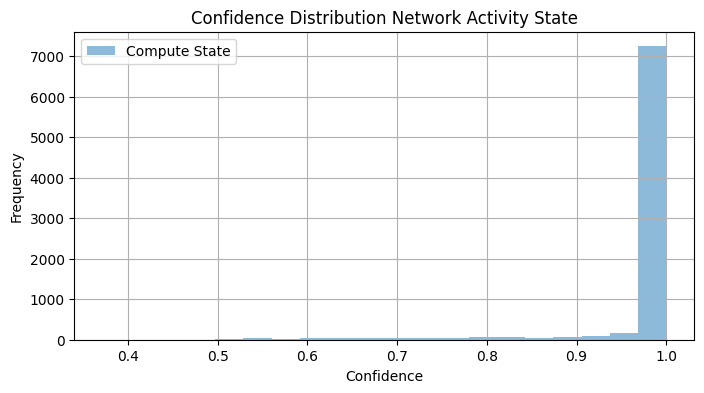

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(class_network, bins=20, alpha=0.5, label='Compute State')
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution Network Activity State")
plt.legend()
plt.grid(True)

In [31]:
# Inference
df_ann_cleaned['inference_time_ms'].describe()

count     23118.000000
mean         21.003073
std        1012.010864
min           0.665885
25%           2.156784
50%           7.817890
75%          13.361784
max      145260.367400
Name: inference_time_ms, dtype: float64

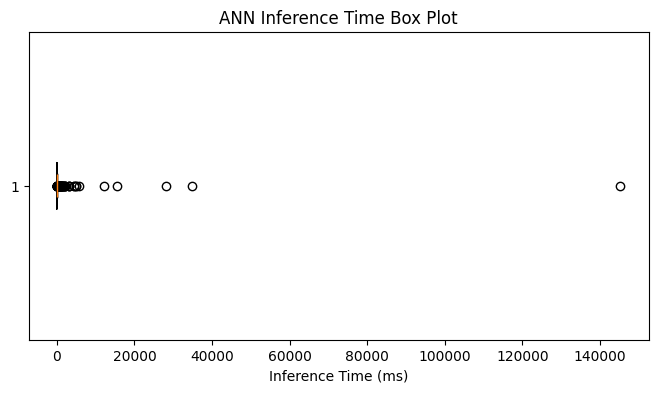

In [36]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_ann_cleaned['inference_time_ms'], notch=True, vert=False)
plt.title("ANN Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()